In [24]:
import pandas as pd

In [25]:
space_df = pd.read_csv('C:/Users/wjdah/vscode-workspace/digital-learning-hub/digital_center_analysis/dataFile/learning_center_2024.csv', header=0, engine='python')

In [26]:
user_df = pd.read_csv('C:/Users/wjdah/vscode-workspace/digital-learning-hub/digital_center_analysis/dataFile/learning_user_2024.csv', header=0, engine='python')

In [27]:
space_df.head() # 데이터 전체를 보여주는것이 아니라 앞에서 5개만 보여줌

,관리지역,시군구,배움터명,배움터주소,배움터 유형,이용정원
0,서울특별시,마포구,성산1동 주민센터 4층 디지털배움터,서울특별시 마포구 성산로4길 15 (성산동),거점센터,20
1,서울특별시,강서구,곰달래어르신복지센터,서울특별시 강서구 강서로5길 50 (화곡동),거점센터,25
2,서울특별시,강동구,서울시민대학 동남권 캠퍼스,"서울특별시 강동구 고덕로 399 (고덕동, 고덕센트럴푸르지오)",거점센터,12
3,서울특별시,도봉구,창동아우르네,서울특별시 도봉구 마들로13길 84 (창동),거점센터,25
4,강원특별자치도,춘천시,춘천시청 시민정보화교육장,강원특별자치도 춘천시 삭주로 3 (교동),거점센터,20


In [28]:
user_df.head()

,광역지자체,기초지자체,교육인원
0,강원특별자치도,강릉시,2890
1,강원특별자치도,고성군,46
2,강원특별자치도,동해시,1754
3,강원특별자치도,삼척시,420
4,강원특별자치도,속초시,168


In [29]:
space_df['관리지역'] = space_df['관리지역'].str.strip() # 문자열 양쪽 공백을 제거 => 전라남도 뒤에 공백이 있어서 제거
user_df['광역지자체'] = user_df['광역지자체'].str.strip()

In [30]:
# 각 광역자치별 교육인원 합계 구하기
user_df_sum = user_df.groupby('광역지자체')['교육인원'].sum().reset_index() # reset_index를 써서 데이터프레임으로 만듦

In [31]:
user_df_sum

,광역지자체,교육인원
0,강원특별자치도,20358
1,경기도,53180
2,경상남도,39353
3,경상북도,49718
4,광주광역시,17932
5,대구광역시,30397
6,대전광역시,11764
7,부산광역시,71665
8,서울특별시,37966
9,세종특별자치시,10615


In [32]:
# 각 관리지역별 배움터명 개수 구하기
space_df_count = space_df.groupby('관리지역')['배움터명'].count().reset_index(name='배움터수') # 결과를 데이터프레임으로 만들고 컬럼명을 배움터수로 새로 생성

In [33]:
space_df_count

,관리지역,배움터수
0,강원특별자치도,6
1,경기도,15
2,경상남도,5
3,경상북도,6
4,광주광역시,4
5,대구광역시,5
6,대전광역시,4
7,부산광역시,19
8,서울특별시,11
9,세종특별자치시,3


In [34]:
space_df_count.rename(columns={'관리지역': '광역지자체'}, inplace=True) # 관리지역 컬럼명을 광역지자체로 바꿈

In [35]:
space_df_count.head()

,광역지자체,배움터수
0,강원특별자치도,6
1,경기도,15
2,경상남도,5
3,경상북도,6
4,광주광역시,4


In [36]:
# 광역지자체 기준으로 합쳐서 새로운 데이터프레임 만듦
# how=left : SQL의 Left Join과 비슷
space_df_user_df = pd.merge(user_df_sum, space_df_count, on='광역지자체', how='left') # 광역지자체를 기준으로 사용해 교육인원이 명시 되어있는 지자체는 모두 결과에 포함

In [37]:
space_df_user_df['센터당_평균교육인원'] = space_df_user_df['교육인원'] / space_df_user_df['배움터수'] 

In [38]:
space_df_user_df

,광역지자체,교육인원,배움터수,센터당_평균교육인원
0,강원특별자치도,20358,6,3393.000000
1,경기도,53180,15,3545.333333
2,경상남도,39353,5,7870.600000
3,경상북도,49718,6,8286.333333
4,광주광역시,17932,4,4483.000000
5,대구광역시,30397,5,6079.400000
6,대전광역시,11764,4,2941.000000
7,부산광역시,71665,19,3771.842105
8,서울특별시,37966,11,3451.454545
9,세종특별자치시,10615,3,3538.333333


In [39]:
space_df_avg = space_df.groupby('관리지역')['이용정원'].mean().reset_index() # mean 사용해 관리지역별 이용정원 평균 계산 -> 데이터프레임으로 저장

In [40]:
space_df_avg.rename(columns={'관리지역': '광역지자체', '이용정원': '이용정원_평균'}, inplace=True) # 관리지역 -> 광역지자체 , 이용정원->이용정원_평균으로 이름 바꿈

In [41]:
space_df_avg

,광역지자체,이용정원_평균
0,강원특별자치도,10.000000
1,경기도,8.000000
2,경상남도,16.000000
3,경상북도,18.500000
4,광주광역시,20.000000
5,대구광역시,30.000000
6,대전광역시,22.500000
7,부산광역시,10.526316
8,서울특별시,25.181818
9,세종특별자치시,26.666667


In [42]:
final_result = pd.merge(space_df_user_df, space_df_avg, on='광역지자체', how='left') # 센터당 평균 교육생수와 이용정원 평균 합치기

In [43]:
final_result

,광역지자체,교육인원,배움터수,센터당_평균교육인원,이용정원_평균
0,강원특별자치도,20358,6,3393.000000,10.000000
1,경기도,53180,15,3545.333333,8.000000
2,경상남도,39353,5,7870.600000,16.000000
3,경상북도,49718,6,8286.333333,18.500000
4,광주광역시,17932,4,4483.000000,20.000000
5,대구광역시,30397,5,6079.400000,30.000000
6,대전광역시,11764,4,2941.000000,22.500000
7,부산광역시,71665,19,3771.842105,10.526316
8,서울특별시,37966,11,3451.454545,25.181818
9,세종특별자치시,10615,3,3538.333333,26.666667


In [44]:
final_result['배움터_수업횟수'] = final_result['센터당_평균교육인원'] / final_result['이용정원_평균'] # 센터당_평균교육인원 / 이용정원_평균 해서 한 센터 당 몇 번 가르치는지 계산

In [45]:
final_result

,광역지자체,교육인원,배움터수,센터당_평균교육인원,이용정원_평균,배움터_수업횟수
0,강원특별자치도,20358,6,3393.000000,10.000000,339.300000
1,경기도,53180,15,3545.333333,8.000000,443.166667
2,경상남도,39353,5,7870.600000,16.000000,491.912500
3,경상북도,49718,6,8286.333333,18.500000,447.909910
4,광주광역시,17932,4,4483.000000,20.000000,224.150000
5,대구광역시,30397,5,6079.400000,30.000000,202.646667
6,대전광역시,11764,4,2941.000000,22.500000,130.711111
7,부산광역시,71665,19,3771.842105,10.526316,358.325000
8,서울특별시,37966,11,3451.454545,25.181818,137.061372
9,세종특별자치시,10615,3,3538.333333,26.666667,132.687500


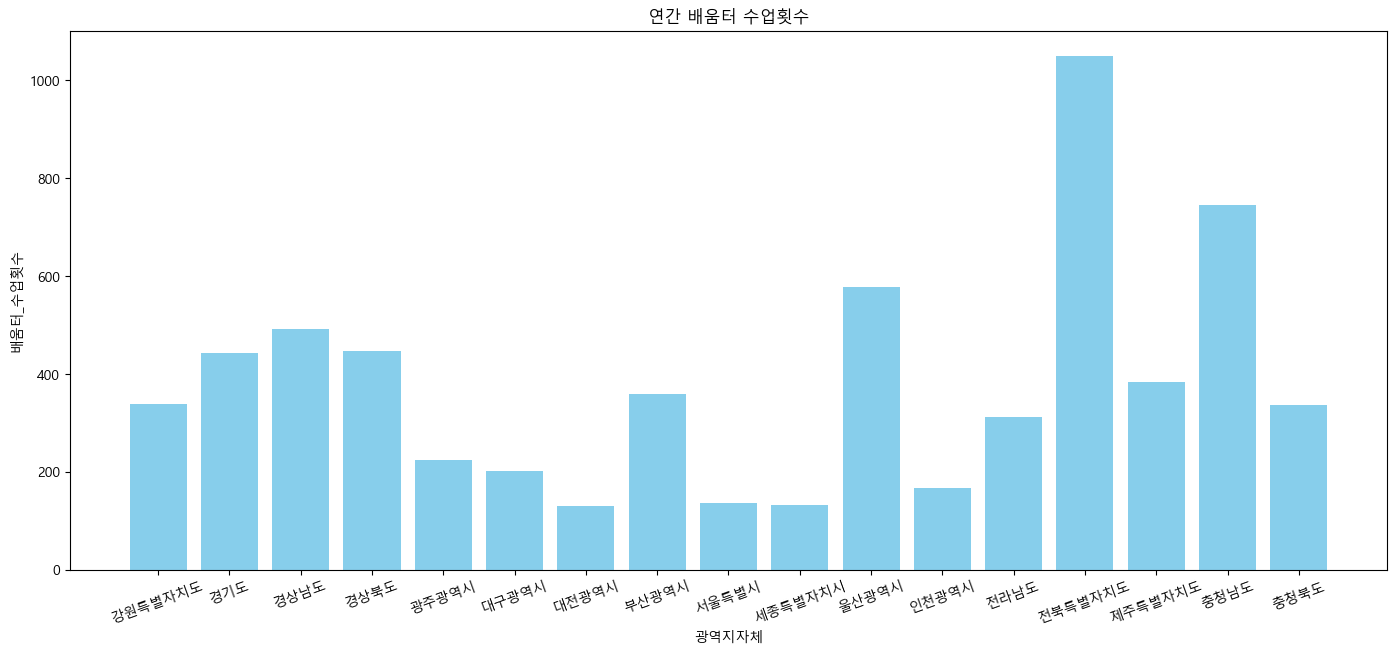

In [46]:
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic') # 한글 깨지는거 방지
plt.rcParams['axes.unicode_minus'] = False # 음수 기호 깨지는거 방지

plt.figure(figsize=(17,7))

plt.bar(final_result['광역지자체'], final_result['배움터_수업횟수'], color = 'skyblue')

plt.title('연간 배움터 수업횟수')
plt.xlabel('광역지자체')
plt.ylabel('배움터_수업횟수')

plt.xticks(rotation = 20)

plt.show()